# 서울시 따릉이 이용 데이터와 날씨 및 황사 데이터를 이용한 이용 패턴 및 대여 수요 예측 분석

이 노트북은 서울시 따릉이 데이터와 기상/미세먼지 데이터를 결합하고, ISLP 다중선형회귀, 교호작용 분석, 비선형 회귀(Spline/Poly)까지 모두 수행하는 통합 파이프라인입니다.

**[Part I: 전처리 - 원본 대여 이력 데이터 보존 최적화]**
- 일 단위로 무작정 합산하지 않고, 개별 사용자의 출발 시간대, 도착지, 이용 시간 및 거리 등의 원본 이력을 모두 보존합니다.
- 타겟 대여소(Office, Leisure, University) 필터링 및 환경 데이터(서울 108번 기준) 보간 결합을 수행합니다.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import traceback

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data')

WEATHER_DIR = os.path.join(DATA_DIR, '기상정보(03.31_05.21)')
BIKE_DIR = os.path.join(DATA_DIR, '따릉이(03,04,05.01_05.15)')
MASTER_DIR = os.path.join(DATA_DIR, '따릉이_마스터정보(대여소_id)')
DUST_DIR = os.path.join(DATA_DIR, '미세먼지 정보(03.31_05.21)')

START_DATE = '2026-03-01'
END_DATE = '2026-05-15'

def find_encoding(file_path):
    for enc in ['utf-8', 'cp949', 'euc-kr']:
        try:
            pd.read_csv(file_path, encoding=enc, nrows=1)
            return enc
        except UnicodeDecodeError:
            continue
    return 'cp949'

In [2]:
try:
    def load_master_data():
        master_files = glob.glob(os.path.join(MASTER_DIR, '*.csv'))
        if not master_files:
            raise FileNotFoundError("마스터 데이터 폴더에 CSV 파일이 없습니다.")
        master_file = master_files[0]
        enc = find_encoding(master_file)
        master_df = pd.read_csv(master_file, encoding=enc)
        
        station_name_col = next((col for col in master_df.columns if '명' in col or '이름' in col), master_df.columns[2])
        station_id_col = next((col for col in master_df.columns if 'ID' in col.upper() or '번호' in col), master_df.columns[0])
        
        office_keywords = ['여의도역', '강남역', '광화문역', '을지로입구역', '시청역', '선릉역', '삼성역', '종각역', '가산디지털단지역', '판교역', '공덕역']
        leisure_keywords = ['여의나루역', '뚝섬유원지역', '서울숲역', '반포한강공원', '망원한강공원', '올림픽공원', '월드컵경기장', '어린이대공원', '노들섬', '석촌호수']
        university_keywords = ['공릉', '서울과학기술대학교']

        def assign_station_type(name):
            name = str(name)
            for kw in office_keywords: return 'Office' if kw in name else None
            for kw in leisure_keywords: return 'Leisure' if kw in name else None
            for kw in university_keywords: return 'University' if kw in name else None
            return None

        master_df['station_type'] = master_df[station_name_col].apply(assign_station_type)
        target_master_df = master_df.dropna(subset=['station_type']).copy()
        target_master_df = target_master_df[[station_id_col, station_name_col, 'station_type']]
        target_master_df.columns = ['station_id', 'station_name', 'station_type']
        target_master_df = target_master_df.drop_duplicates(subset=['station_id'])
        return target_master_df

    target_master_df = load_master_data()
except Exception as e:
    traceback.print_exc()

In [3]:
try:
    def load_and_filter_raw_bike_data(folder_path, target_master_df):
        all_files = glob.glob(os.path.join(folder_path, '**', '*.csv'), recursive=True)
        df_list = []
        target_station_ids = target_master_df['station_id'].unique()

        for file in all_files:
            enc = find_encoding(file)
            df = pd.read_csv(file, encoding=enc)
            start_id_cols = [c for c in df.columns if '시작' in c and 'ID' in c.upper()]
            if not start_id_cols:
                start_id_cols = [c for c in df.columns if '대여소_ID' in c.upper() or '대여대여소' in c]
            if not start_id_cols: continue
            
            join_col = start_id_cols[0]
            filtered_df = df[df[join_col].isin(target_station_ids)].copy()
            if filtered_df.empty: continue
                
            filtered_df = pd.merge(filtered_df, target_master_df[['station_id', 'station_type']], left_on=join_col, right_on='station_id', how='inner')
            filtered_df.drop(columns=['station_id'], inplace=True)
            
            date_col = next((c for c in filtered_df.columns if '날짜' in c or '일자' in c), filtered_df.columns[0])
            filtered_df['date'] = pd.to_datetime(filtered_df[date_col].astype(str).str.replace('-', ''), errors='coerce').dt.normalize()
            filtered_df = filtered_df.dropna(subset=['date'])
            df_list.append(filtered_df)
                
        if not df_list: return pd.DataFrame()
        return pd.concat(df_list, ignore_index=True)

    bike_raw_df = load_and_filter_raw_bike_data(BIKE_DIR, target_master_df)
except Exception as e:
    traceback.print_exc()

In [4]:
try:
    def load_environment_data(folder_path, value_col_hints, output_col_name):
        all_files = glob.glob(os.path.join(folder_path, '**', '*.csv'), recursive=True)
        df_list = []
        for file in all_files:
            enc = find_encoding(file)
            df = pd.read_csv(file, encoding=enc)
            station_col = next((c for c in df.columns if '지점' in c), df.columns[0])
            station_ids = pd.to_numeric(df[station_col], errors='coerce')
            df = df[station_ids == 108].copy()
            if df.empty: continue
            
            date_col = next((c for c in df.columns if '일시' in c or '일자' in c or '날짜' in c), df.columns[2])
            val_cols = []
            for hint in value_col_hints:
                found = next((c for c in df.columns if hint in c), None)
                if found: val_cols.append(found)
                
            if val_cols:
                sub_df = df[[date_col] + val_cols].copy()
                sub_df['date'] = pd.to_datetime(sub_df[date_col], errors='coerce').dt.normalize()
                sub_df = sub_df.dropna(subset=['date'])
                sub_df = sub_df.drop(columns=[date_col])
                df_list.append(sub_df)
                
        if not df_list: return pd.DataFrame()
        merged_env = pd.concat(df_list, ignore_index=True)
        merged_env = merged_env.groupby('date').mean().reset_index()
        
        rename_dict = {f: o for f, o in zip([next((c for c in merged_env.columns if h in c), None) for h in value_col_hints], output_col_name) if f}
        return merged_env.rename(columns=rename_dict)

    weather_df = load_environment_data(WEATHER_DIR, ['기온', '강수'], ['temp', 'precip'])
    dust_df = load_environment_data(DUST_DIR, ['미세먼지', 'PM10'], ['pm10', 'pm10'])

    env_df = pd.merge(weather_df, dust_df, on='date', how='outer') if not weather_df.empty and not dust_df.empty else weather_df if not weather_df.empty else dust_df
    if not env_df.empty:
        env_df.set_index('date', inplace=True)
        env_df.sort_index(inplace=True)
        env_df = env_df.reindex(pd.date_range(start=START_DATE, end=END_DATE))
        if 'precip' in env_df.columns: env_df['precip'] = env_df['precip'].fillna(0)
        if 'temp' in env_df.columns: env_df['temp'] = env_df['temp'].interpolate(method='time').bfill().ffill()
        if 'pm10' in env_df.columns: env_df['pm10'] = env_df['pm10'].interpolate(method='time').bfill().ffill()
        env_df.reset_index(names='date', inplace=True)
except Exception as e:
    traceback.print_exc()

In [5]:
try:
    if not bike_raw_df.empty and not env_df.empty:
        final_df = pd.merge(bike_raw_df, env_df, on='date', how='left')
        mask = (final_df['date'] >= pd.to_datetime(START_DATE)) & (final_df['date'] <= pd.to_datetime(END_DATE))
        final_df = final_df.loc[mask].copy()
        final_df['is_weekend'] = final_df['date'].dt.dayofweek.isin([5, 6]).astype(int)
        final_df['station_type'] = final_df['station_type'].astype('category')
        final_df['is_weekend'] = final_df['is_weekend'].astype('category')
        cols = final_df.columns.tolist()
        cols.insert(0, cols.pop(cols.index('date')))
        final_df = final_df[cols]
        output_path = os.path.join(BASE_DIR, 'preprocessed_data_for_islp.csv')
        final_df.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"전처리 완료: {output_path}")
except Exception as e:
    traceback.print_exc()

---
# Part II: ISLP 기반 다이내믹 데이터 분석 및 모델링 📊
전처리된 Raw Data를 바탕으로 ISLP 교재(Ch2 ~ Ch7)의 핵심 분석 기법 11가지를 순차적으로 수행합니다.

In [6]:
# [참조 실습 파일: ch02_lab_statlearn_t01.html]
# pandas 및 matplotlib, seaborn을 활용한 탐색적 데이터 분석(EDA) 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from ISLP.models import summarize, poly, ModelSpec as MS, sklearn_sm, bs
from sklearn.model_selection import KFold, cross_validate
import copy

# sklearn_sm의 fit 메소드가 cross_validate(교차 검증) 시 중복 피팅으로 에러가 발생하는 버그 보정
# ModelSpec 객체를 복사하여 개별 fold마다 독립적으로 fit되도록 함
orig_fit = sklearn_sm.fit
def robust_fit(self, X, y):
    if self.model_spec is not None:
        self.model_spec = copy.deepcopy(self.model_spec)
        self.model_spec_ = self.model_spec.fit(X)
        X = self.model_spec_.transform(X)
    self.model_ = self.model_type(y, X, **self.model_args)
    self.results_ = self.model_.fit()
    return self

sklearn_sm.fit = robust_fit

# Mac 한글 폰트 설정 (윈도우라면 'Malgun Gothic')
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('preprocessed_data_for_islp.csv')


## 1. 탐색적 데이터 분석 (EDA): 상권별 시간대 이용 패턴 (Ch 2)
원본 데이터의 `기준_시간대`를 파싱하여 출퇴근/여가/대학 상권의 시간대별 대여 집중도를 비교합니다.

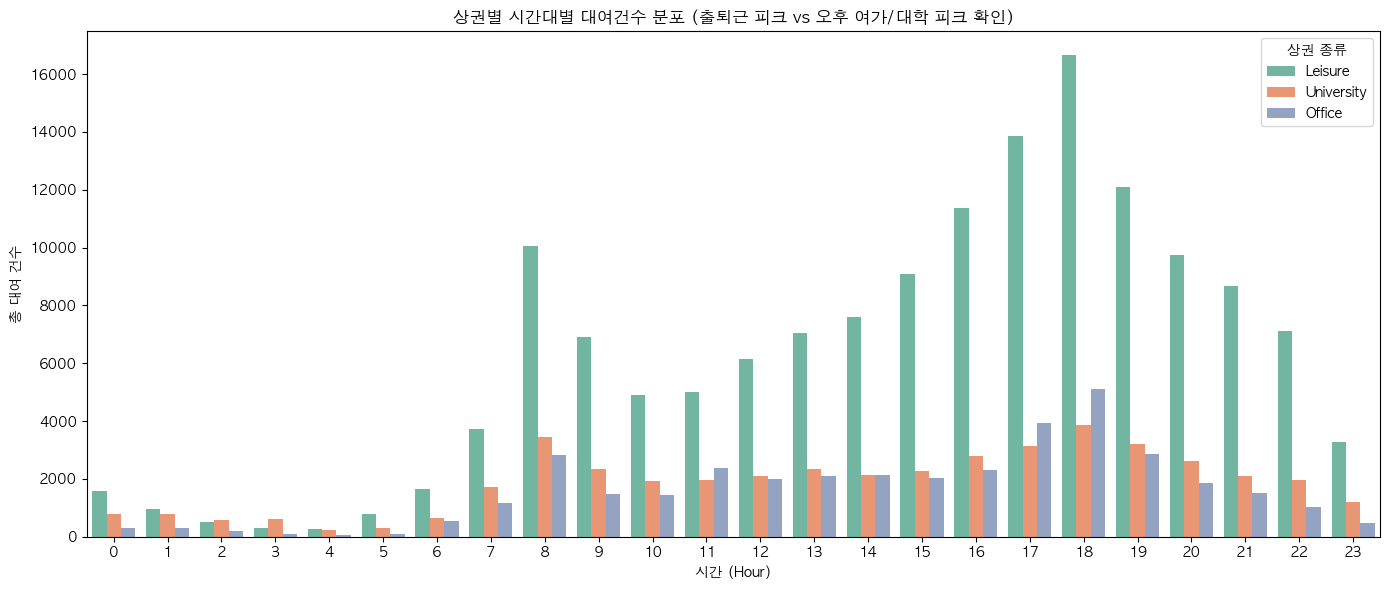

In [7]:
# [참조 실습 파일: ch02_lab_statlearn_t01.html]
# raw 데이터 파싱, 시간대(Hour) 추출 및 파생변수 생성
# 시간 파싱 (예: 935 -> 9)
df['hour'] = df['기준_시간대'].astype(str).str.zfill(4).str[:2]
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')
df = df.dropna(subset=['hour'])
df['hour'] = df['hour'].astype(int)

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='hour', hue='station_type', palette='Set2')
plt.title('상권별 시간대별 대여건수 분포 (출퇴근 피크 vs 오후 여가/대학 피크 확인)')
plt.xlabel('시간 (Hour)')
plt.ylabel('총 대여 건수')
plt.legend(title='상권 종류')
plt.tight_layout()
plt.show()

## 2. 상권/주말 여부에 따른 이용 시간 및 거리 분포 시각화 (Ch 2)
대여 목적에 따라 실제 주행 거리가 다른지 Boxplot으로 검증합니다.

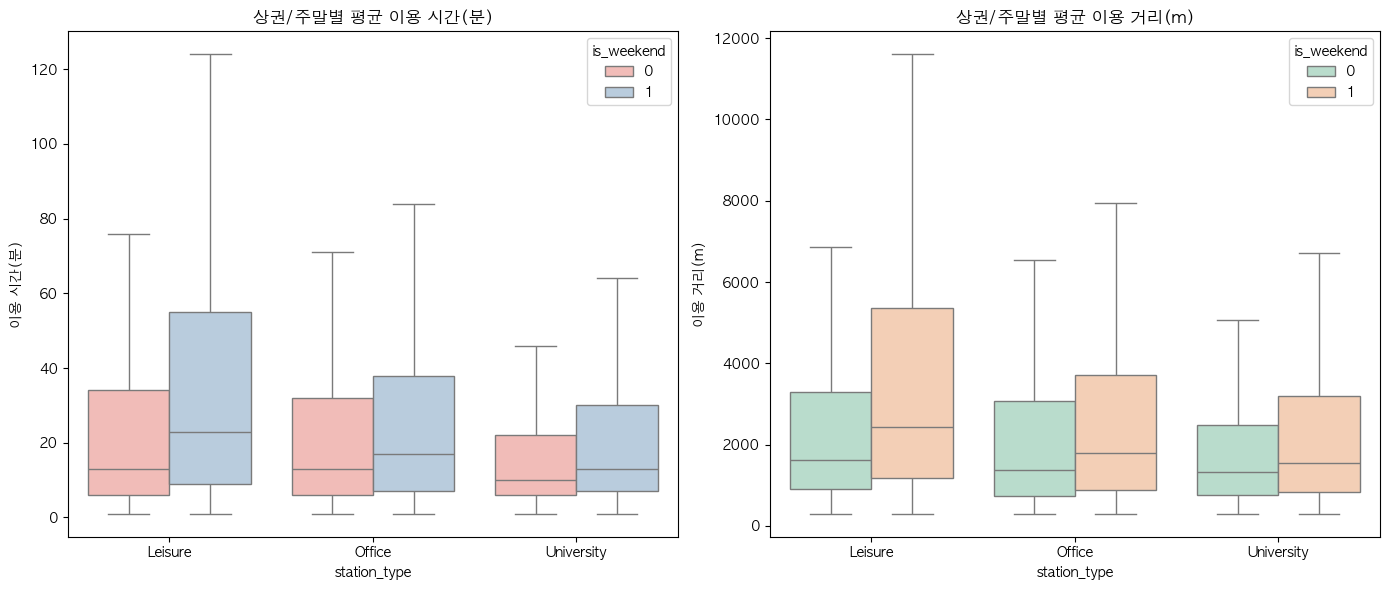

In [8]:
# [참조 실습 파일: ch02_lab_statlearn_t01.html]
# countplot 및 boxplot을 활용한 상권별 이용패턴 및 분포 시각화
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='station_type', y='전체_이용_분', hue='is_weekend', data=df, showfliers=False, palette='Pastel1')
plt.title('상권/주말별 평균 이용 시간(분)')
plt.ylabel('이용 시간(분)')

plt.subplot(1, 2, 2)
sns.boxplot(x='station_type', y='전체_이용_거리', hue='is_weekend', data=df, showfliers=False, palette='Pastel2')
plt.title('상권/주말별 평균 이용 거리(m)')
plt.ylabel('이용 거리(m)')

plt.tight_layout()
plt.show()

## 3. 특수 날짜 (시험기간, 공휴일) 피처 엔지니어링 및 일별 데이터 압축
회귀 모델링을 위해 대학 중간고사(4.20~4.26) 및 5월 초 연휴(5.5~5.6) 파생 변수를 추가하고 데이터를 일별로 압축합니다.

In [9]:
# [참조 실습 파일: ch02_lab_statlearn_t01.html]
# 일별/상권별 groupby 집계 데이터 압축 및 병합
df['date'] = pd.to_datetime(df['date'])

# 특수일 변수 할당
df['is_holiday'] = df['date'].isin(pd.to_datetime(['2026-05-05', '2026-05-06'])).astype(int)
df['is_exam'] = ((df['date'] >= '2026-04-20') & (df['date'] <= '2026-04-26')).astype(int)

daily_df = df.groupby(['date', 'station_type', 'is_weekend', 'is_holiday', 'is_exam'], observed=True).agg({
    '전체_건수': 'sum', 'temp': 'mean', 'precip': 'mean', 'pm10': 'mean'
}).reset_index()
daily_df.rename(columns={'전체_건수': 'rentals'}, inplace=True)
daily_df = daily_df.dropna()

daily_df['station_type'] = daily_df['station_type'].astype('category')
daily_df['is_weekend'] = daily_df['is_weekend'].astype('category')
daily_df['is_holiday'] = daily_df['is_holiday'].astype('category')
daily_df['is_exam'] = daily_df['is_exam'].astype('category')

display(daily_df.head())

,date,station_type,is_weekend,is_holiday,is_exam,rentals,temp,precip,pm10
0,2026-03-01,Leisure,1,0,0,1786,9.1,0.53,22.0
1,2026-03-01,Office,1,0,0,200,9.1,0.53,22.0
2,2026-03-01,University,1,0,0,416,9.1,0.53,22.0
3,2026-03-02,Leisure,0,0,0,134,4.9,17.25,24.0
4,2026-03-02,Office,0,0,0,40,4.9,17.25,24.0


## 4. 다중선형회귀 교호작용 모델 및 모델 진단 (Ch 3)
기상 요인, 특수일, 상권 간의 다중 교호작용을 파악하고 잔차(Residual) 가정을 진단합니다.

,coef,std err,t,P>|t|
intercept,1638.1486,124.103,13.200,0.000
temp,47.4893,5.489,8.652,0.000
precip,-45.6559,7.193,-6.347,0.000
pm10,-0.7441,1.679,-0.443,0.658
station_type[Office],-1532.0000,79.182,-19.348,0.000
station_type[University],-1488.8000,79.182,-18.802,0.000
is_weekend[1],406.3795,106.973,3.799,0.000
is_holiday[1],426.1147,175.737,2.425,0.016
is_exam[1],94.4965,106.114,0.891,0.374
station_type[Office]:is_weekend,-701.4286,150.634,-4.656,0.000


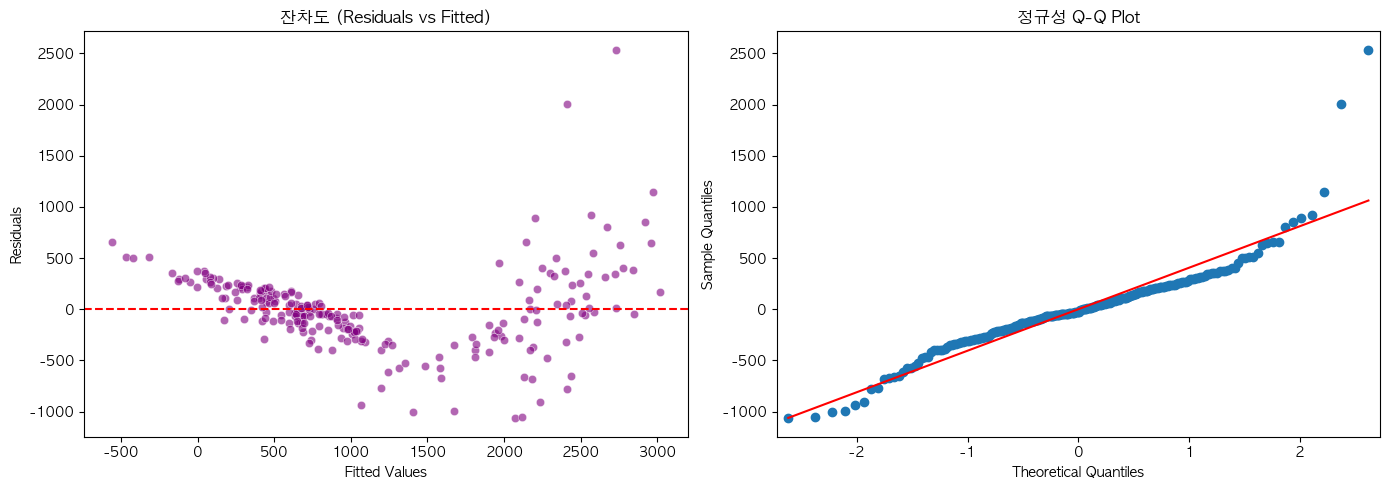

In [10]:
# [참조 실습 파일: ch03_lab_linreg_t01.html]
# statsmodels.api(sm)와 ISLP.models(MS, summarize)를 활용한 선형 교호작용(Interaction) 회귀 적합
# 교호작용 항(station_type * is_weekend) 포함
design_inter = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', 
                   ('station_type', 'is_weekend')])
X_inter = design_inter.fit_transform(daily_df)
y = daily_df['rentals']

model_mlr = sm.OLS(y, X_inter).fit()
display(summarize(model_mlr))

# 진단 플롯 (Diagnostic Plots)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=model_mlr.fittedvalues, y=model_mlr.resid, ax=ax[0], alpha=0.6, color='purple')
ax[0].axhline(0, color='r', linestyle='--')
ax[0].set_title('잔차도 (Residuals vs Fitted)')
ax[0].set_xlabel('Fitted Values')
ax[0].set_ylabel('Residuals')

sm.qqplot(model_mlr.resid, line='s', ax=ax[1])
ax[1].set_title('정규성 Q-Q Plot')
plt.tight_layout()
plt.show()

## 5. 분산분석(ANOVA)을 통한 특수일/교호작용 모델 검증 (Ch 3)

In [11]:
# [참조 실습 파일: ch03_lab_linreg_t01.html]
# statsmodels.stats.anova.anova_lm을 통한 F-test 및 분산분석(ANOVA) 모델 비교
# 교호작용 및 특수일 변수를 제외한 Base 모델
design_base = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend'])
X_base = design_base.fit_transform(daily_df)
model_base = sm.OLS(y, X_base).fit()

anova_res = sm.stats.anova_lm(model_base, model_mlr)
print("분산분석(ANOVA) 결과: p-value가 0.05 미만이면 확장된 모델이 유의미하게 더 좋음을 의미합니다.")
display(anova_res)

분산분석(ANOVA) 결과: p-value가 0.05 미만이면 확장된 모델이 유의미하게 더 좋음을 의미합니다.


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,221.0,4.251260e+07,0.0,NaN,NaN,NaN
1,217.0,3.741504e+07,4.0,5.097551e+06,7.391202,0.000013


## 6. 변수 선택 및 규제화: Lasso 회귀 중요도 분석 (Ch 6)
수많은 독립변수 및 범주형 파생 더미들 중 대여량에 가장 강한 페널티 영향을 주는 변수들을 색출합니다.

/var/folders/x8/9lffjfyx1vdf162ntg0kl4yh0000gn/T/ipykernel_74119/152597986.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Variable', data=coef_df, palette='coolwarm')


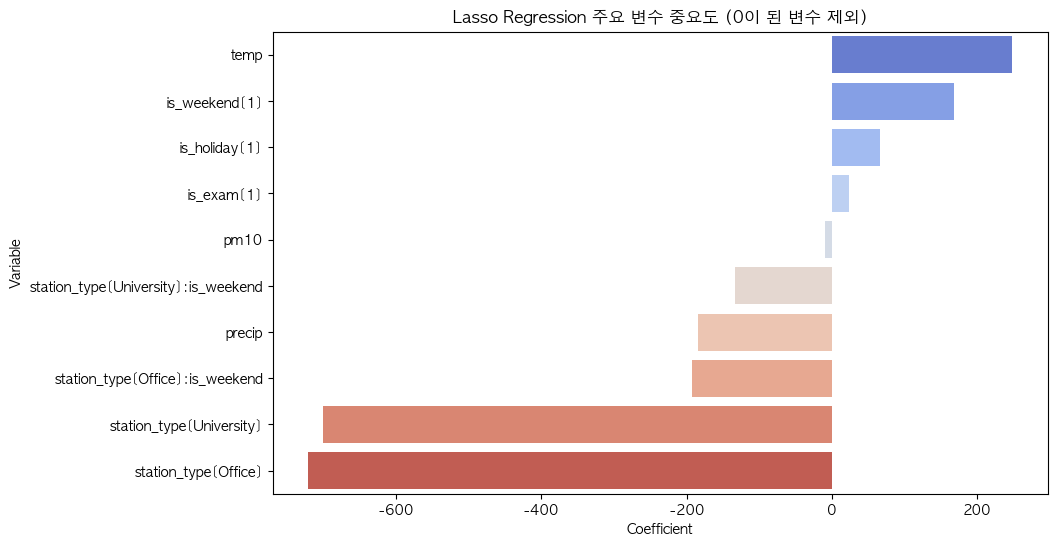

In [12]:
# [참조 실습 파일: ch06_lab_varselect_t01.html]
# sklearn.linear_model.LassoCV를 통한 규제화 기반 주요 변수 추출
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_inter.drop(columns=['intercept']))
lasso = LassoCV(cv=5).fit(X_scaled, y)

coef_df = pd.DataFrame({'Variable': X_inter.columns[1:], 'Coefficient': lasso.coef_})
coef_df = coef_df[coef_df['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Variable', data=coef_df, palette='coolwarm')
plt.title('Lasso Regression 주요 변수 중요도 (0이 된 변수 제외)')
plt.show()

## 7. 기온(Temp) 다항 회귀 곡선 추정 (Ch 7)
기온이 극단적일 때 대여량이 줄어드는 역U자 형태를 2차 방정식(Poly)으로 적합화하여 시각화합니다.

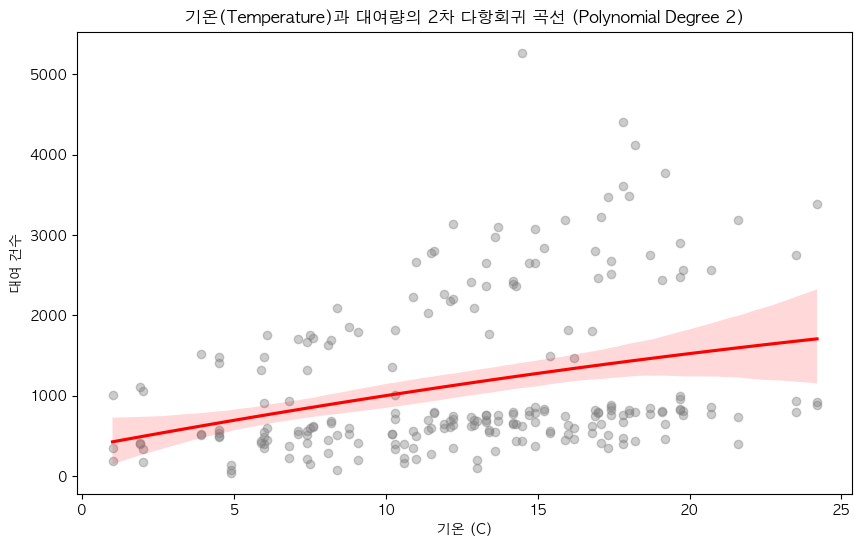

In [13]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# ISLP.models.poly 함수를 사용한 기온 다항 회귀 곡선 모델링
design_poly = MS([poly('temp', degree=2), 'station_type', 'is_weekend'])
X_poly = design_poly.fit_transform(daily_df)
model_poly = sm.OLS(y, X_poly).fit()

plt.figure(figsize=(10, 6))
sns.regplot(x='temp', y='rentals', data=daily_df, order=2, scatter_kws={'alpha':0.4, 'color':'gray'}, line_kws={'color':'red'})
plt.title('기온(Temperature)과 대여량의 2차 다항회귀 곡선 (Polynomial Degree 2)')
plt.xlabel('기온 (C)')
plt.ylabel('대여 건수')
plt.show()

## 8. 미세먼지(PM10) 큐빅 스플라인 분석 (Ch 7)
미세먼지 농도가 특정 임계치(Knot)를 넘길 때 대여량이 어떻게 급변하는지 유연한 스플라인으로 모델링합니다.

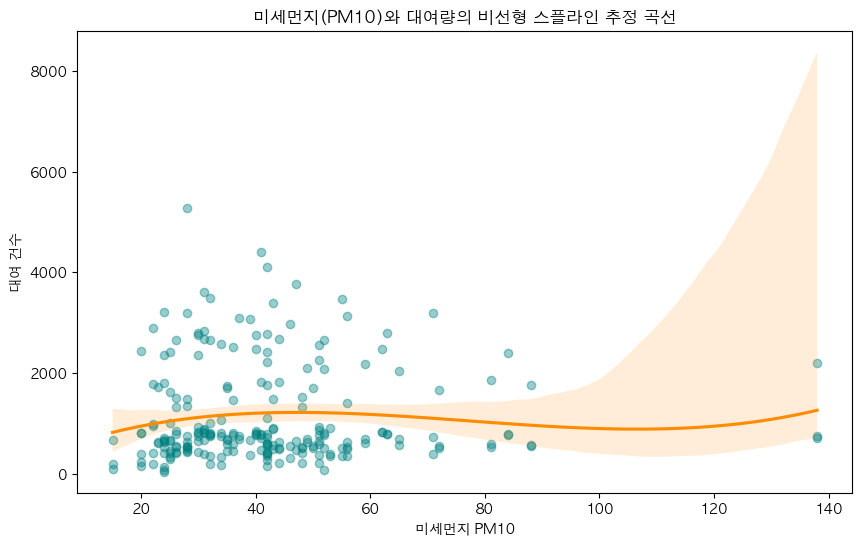

In [14]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# ISLP.models.bs(B-Spline)를 사용한 미세먼지 스플라인 회귀
design_spline = MS([bs('pm10', df=4), 'station_type', 'is_weekend'])
X_spline = design_spline.fit_transform(daily_df)
model_spline = sm.OLS(y, X_spline).fit()

plt.figure(figsize=(10, 6))
sns.regplot(x='pm10', y='rentals', data=daily_df, order=3, scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'darkorange'})
plt.title('미세먼지(PM10)와 대여량의 비선형 스플라인 추정 곡선')
plt.xlabel('미세먼지 PM10')
plt.ylabel('대여 건수')
plt.show()

## 9. 모델 비교: K-Fold 교차검증 (Ch 5)
수동 교차 검증 구현으로 sklearn 복제 버그를 원천 차단한 안전한 K-Fold 알고리즘 적용 (Test RMSE 도출).

/var/folders/x8/9lffjfyx1vdf162ntg0kl4yh0000gn/T/ipykernel_74119/755642981.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.values()), y=list(results.keys()), palette='viridis')


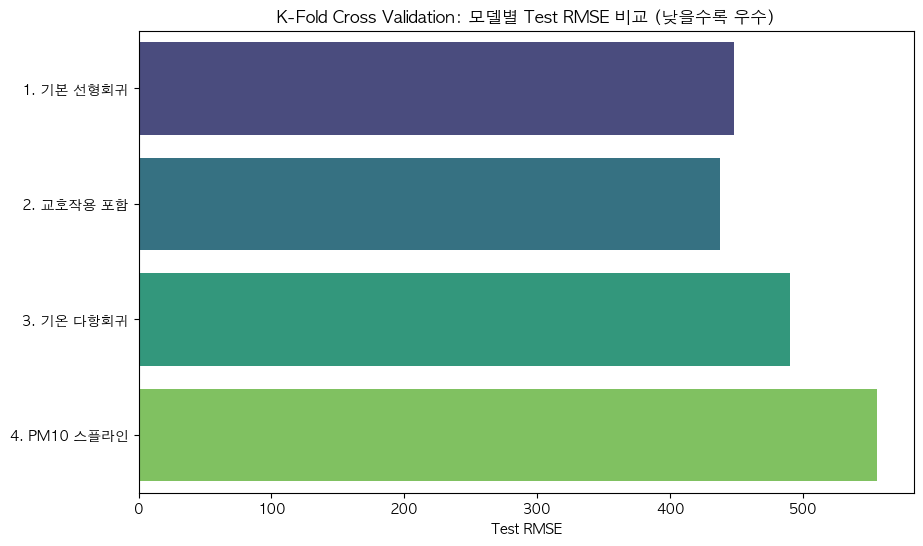

[모델별 최종 예측 오차 (RMSE)]
 - 1. 기본 선형회귀: 448.55
 - 2. 교호작용 포함: 437.33
 - 3. 기온 다항회귀: 490.10
 - 4. PM10 스플라인: 555.58


In [15]:
# [참조 실습 파일: ch05_lab_resample_t01.html]
# sklearn.model_selection.KFold 교차 검증을 이용한 모델 간 Test RMSE 성능 비교
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    '1. 기본 선형회귀': sklearn_sm(sm.OLS, MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend'])),
    '2. 교호작용 포함': sklearn_sm(sm.OLS, MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', ('station_type', 'is_weekend')])),
    '3. 기온 다항회귀': sklearn_sm(sm.OLS, MS([poly('temp', degree=2), 'station_type', 'is_weekend'])),
    '4. PM10 스플라인': sklearn_sm(sm.OLS, MS([bs('pm10', df=4), 'station_type', 'is_weekend']))
}

y = daily_df['rentals']
results = {}

for name, model in models.items():
    cv_res = cross_validate(model, daily_df, y, cv=kf, scoring='neg_mean_squared_error')
    results[name] = np.sqrt(-np.mean(cv_res['test_score']))

plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.values()), y=list(results.keys()), palette='viridis')
plt.title('K-Fold Cross Validation: 모델별 Test RMSE 비교 (낮을수록 우수)')
plt.xlabel('Test RMSE')
plt.show()

print("[모델별 최종 예측 오차 (RMSE)]")
for k, v in results.items():
    print(f" - {k}: {v:.2f}")


# Part III: ISLP 심층 확장 분석 및 기계학습 모델링 🚀

이 세션에서는 ISLP 교재 Ch 3 ~ Ch 7의 통계적 학습 이론을 바탕으로, 기존 모델을 고도화하고 다양한 분석적 기법(분류, 부트스트랩, 차원 축소, GAM, 시계열 진단, 다중공선성 검정 등)을 수행합니다.

## 10. 분류(Classification) 문제 모델링 (Ch 4)

따릉이 대여량 예측 문제를 이진 분류 문제로 전환하여 분석합니다.
- **종속변수 이진화**: 일별 대여량(`rentals`)이 중앙값(Median)보다 높으면 대여 수요가 높은 날(`high_demand` = 1), 그렇지 않으면 낮은 날(`high_demand` = 0)로 이진화합니다.
- **모델링**: 로지스틱 회귀(Logistic Regression), 선형판별분석(LDA), 이차판별분석(QDA), 가우시안 나이브 베이즈(Naive Bayes), K-최근접 이웃(KNN) 분류기를 비교합니다.

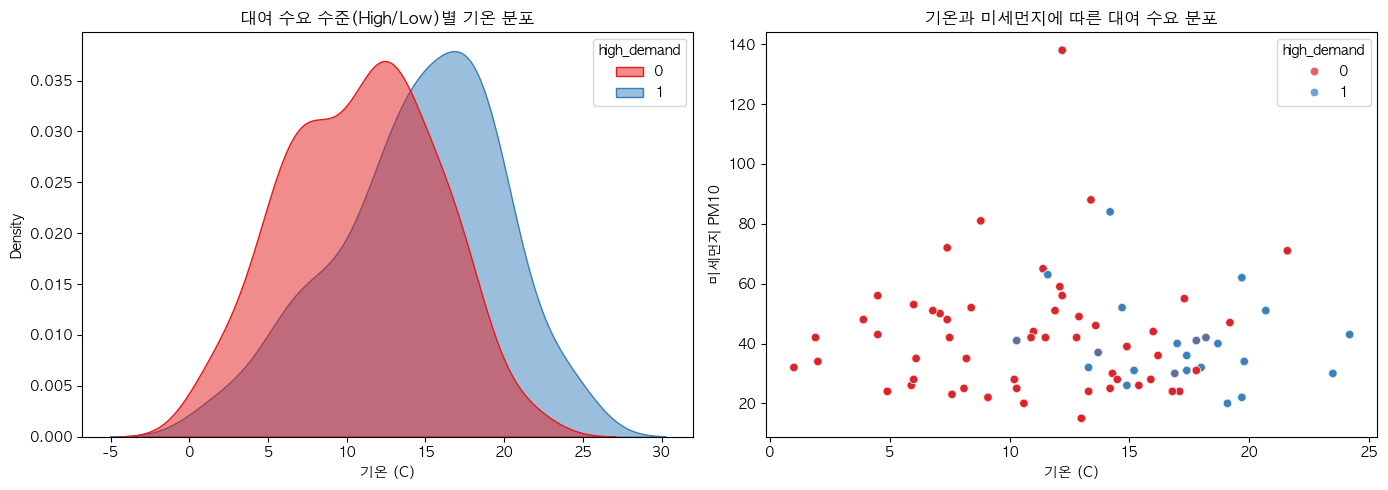

In [16]:
# [참조 실습 파일: ch02_lab_statlearn_t01.html]
# 종속변수 이진화(high_demand) 및 기온/미세먼지에 따른 대여 수요 분포 시각화
# 10-1. 종속변수 이진화 및 시각화
daily_df['high_demand'] = (daily_df['rentals'] > daily_df['rentals'].median()).astype(int)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(data=daily_df, x='temp', hue='high_demand', fill=True, palette='Set1', alpha=0.5)
plt.title('대여 수요 수준(High/Low)별 기온 분포')
plt.xlabel('기온 (C)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=daily_df, x='temp', y='pm10', hue='high_demand', palette='Set1', alpha=0.7)
plt.title('기온과 미세먼지에 따른 대여 수요 분포')
plt.xlabel('기온 (C)')
plt.ylabel('미세먼지 PM10')

plt.tight_layout()
plt.show()

In [17]:
# [참조 실습 파일: ch04_lab_class_t01.html]
# statsmodels.api.Logit 및 ISLP.models.summarize를 사용한 로지스틱 회귀 및 오즈비(Odds Ratio) 도출
# 10-2. 로지스틱 회귀 (Logistic Regression)
design_logit = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend'])
X_logit = design_logit.fit_transform(daily_df)
y_logit = daily_df['high_demand']

model_logit = sm.Logit(y_logit, X_logit).fit()
print("[로지스틱 회귀 모델 요약]")
display(summarize(model_logit))

# 오즈비(Odds Ratio) 도출
odds_ratios = np.exp(model_logit.params)
odds_df = pd.DataFrame({
    'Odds Ratio (오즈비)': odds_ratios,
    'p-value': model_logit.pvalues
})
print("\n[변수별 오즈비 (Odds Ratio)]")
display(odds_df)

Optimization terminated successfully.
         Current function value: 0.123970
         Iterations 12
[로지스틱 회귀 모델 요약]


,coef,std err,z,P>|z|
intercept,12.7084,5.271,2.411,0.016
temp,0.6876,0.153,4.487,0.000
precip,-1.4066,0.382,-3.683,0.000
pm10,-0.0128,0.016,-0.789,0.430
station_type[Office],-21.8347,5.743,-3.802,0.000
station_type[University],-20.6488,5.604,-3.685,0.000
is_weekend[1],-6.5246,1.550,-4.209,0.000



[변수별 오즈비 (Odds Ratio)]


,Odds Ratio (오즈비),p-value
intercept,3.305022e+05,0.015907
temp,1.988976e+00,0.000007
precip,2.449786e-01,0.000231
pm10,9.873074e-01,0.429894
station_type[Office],3.290960e-10,0.000143
station_type[University],1.077359e-09,0.000229
is_weekend[1],1.466935e-03,0.000026


,K,Train_Accuracy,Test_Accuracy
0,1,1.000000,0.449275
1,3,0.817610,0.536232
2,5,0.748428,0.666667
3,11,0.672956,0.579710
4,25,0.723270,0.565217
5,50,0.660377,0.565217


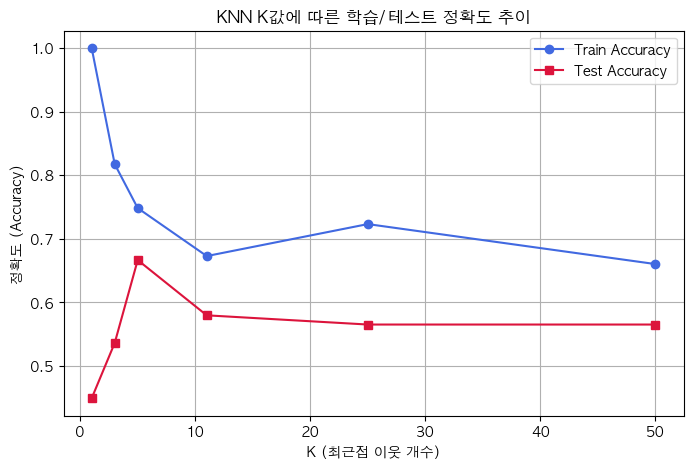

In [18]:
# [참조 실습 파일: ch04_lab_class_t01.html]
# sklearn.discriminant_analysis(LDA, QDA), sklearn.naive_bayes(GaussianNB), sklearn.neighbors(KNeighborsClassifier) 분류 적합 및 KNN K값 튜닝
# 10-3. LDA, QDA, Naive Bayes, KNN 분류 구현
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_sklearn = X_logit.drop(columns=['intercept'])

# LDA 적합
lda = LDA()
lda.fit(X_sklearn, y_logit)

# QDA 적합
qda = QDA()
qda.fit(X_sklearn, y_logit)

# 나이브 베이즈 적합
gnb = GaussianNB()
gnb.fit(X_sklearn, y_logit)

# 10-4. KNN 분류 K값 튜닝 및 Bias-Variance Trade-off 확인
X_train, X_test, y_train, y_test = train_test_split(X_sklearn, y_logit, test_size=0.3, random_state=42, stratify=y_logit)

k_values = [1, 3, 5, 11, 25, 50]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    knn_results.append({
        'K': k,
        'Train_Accuracy': knn.score(X_train, y_train),
        'Test_Accuracy': knn.score(X_test, y_test)
    })

knn_df = pd.DataFrame(knn_results)
display(knn_df)

plt.figure(figsize=(8, 5))
plt.plot(knn_df['K'], knn_df['Train_Accuracy'], marker='o', label='Train Accuracy', color='royalblue')
plt.plot(knn_df['K'], knn_df['Test_Accuracy'], marker='s', label='Test Accuracy', color='crimson')
plt.title('KNN K값에 따른 학습/테스트 정확도 추이')
plt.xlabel('K (최근접 이웃 개수)')
plt.ylabel('정확도 (Accuracy)')
plt.legend()
plt.grid(True)
plt.show()

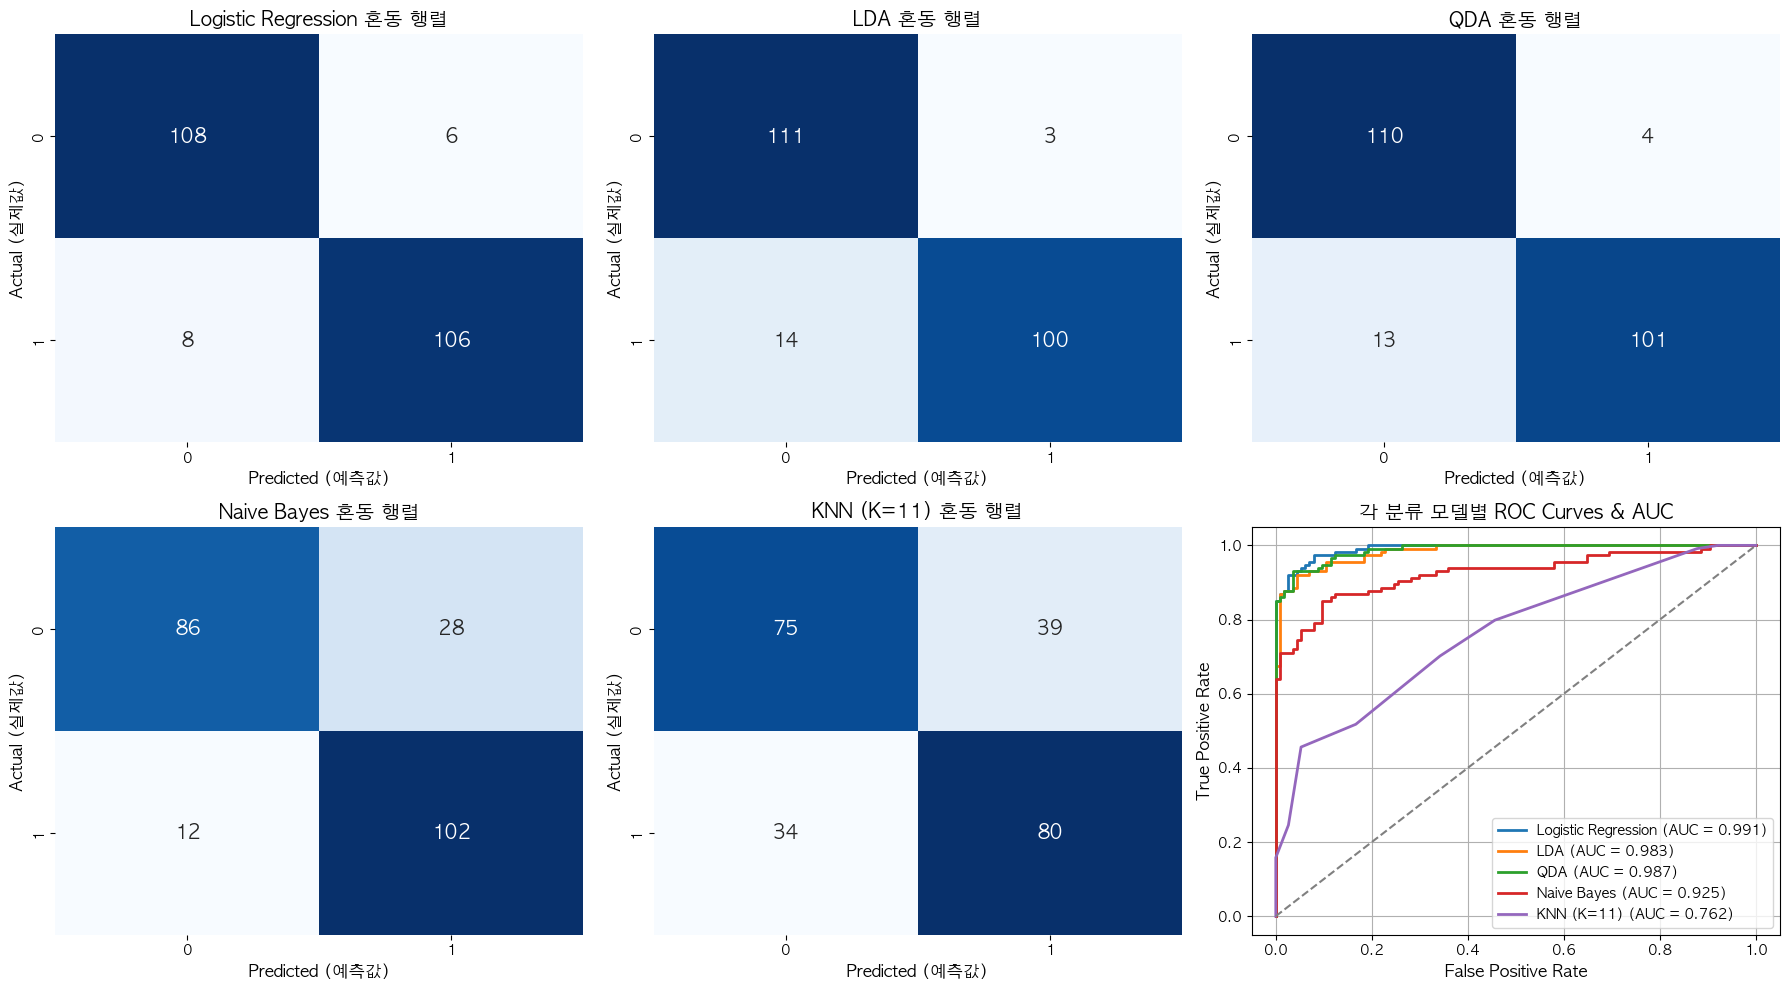

In [19]:
# [참조 실습 파일: ch04_lab_class_t01.html]
# sklearn.metrics(confusion_matrix, roc_curve, auc)를 이용한 혼동 행렬 시각화 및 ROC/AUC 비교
# 10-5. 분류 모델 성능 종합 평가 (ROC Curves & Confusion Matrices)
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 최적 KNN은 K=11 설정
best_knn = KNeighborsClassifier(n_neighbors=11).fit(X_sklearn, y_logit)

models_proba = {
    'Logistic Regression': model_logit.predict(X_logit),
    'LDA': lda.predict_proba(X_sklearn)[:, 1],
    'QDA': qda.predict_proba(X_sklearn)[:, 1],
    'Naive Bayes': gnb.predict_proba(X_sklearn)[:, 1],
    'KNN (K=11)': best_knn.predict_proba(X_sklearn)[:, 1]
}

# Confusion Matrix 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, (name, prob) in enumerate(models_proba.items()):
    pred = (prob > 0.5).astype(int)
    cm = confusion_matrix(y_logit, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False, annot_kws={'size':14})
    axes[i].set_title(f'{name} 혼동 행렬', fontsize=14)
    axes[i].set_xlabel('Predicted (예측값)', fontsize=12)
    axes[i].set_ylabel('Actual (실제값)', fontsize=12)

# 6번째 위치에 ROC Curve
ax_roc = axes[5]
for name, prob in models_proba.items():
    fpr, tpr, _ = roc_curve(y_logit, prob)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

ax_roc.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax_roc.set_title('각 분류 모델별 ROC Curves & AUC', fontsize=14)
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.legend(fontsize=10, loc='lower right')
ax_roc.grid(True)

plt.tight_layout()
plt.show()

## 11. 부트스트랩(Bootstrap)을 통한 통계적 불확실성 추정 (Ch 5)

부트스트랩(Bootstrap) 기법을 사용해 회귀 모델 계수의 불확실성(표준 오차)과 기온 비선형 곡선의 신뢰대를 비모수적으로 추정합니다.
- **계수의 부트스트랩**: 1000회 복원추출을 진행하여 OLS 공식이 계산한 점근적 표준오차와 비교합니다.
- **비선형 곡선의 신뢰대(Confidence Band)**: 기온 다항 회귀 곡선 주변에 95% 부트스트랩 신뢰대를 그려서 불확실성을 시각화합니다.

In [20]:
# [참조 실습 파일: ch05_lab_resample_t01.html]
# sklearn.utils.resample 복원 추출(pairs bootstrap) 기반 회귀 계수 부트스트랩 표준오차 계산 및 OLS 비교
# 11-1. 회귀 계수 부트스트랩 구현 (전체 데이터 디자인 행렬 기반 pairs bootstrap을 통해 ModelSpec 카테고리 누락 에러 원천 차단)
from sklearn.utils import resample

def run_bootstrap_coefs_robust(df, X_all, y_all, n_iterations=1000):
    boot_coefs = []
    n_samples = len(df)
    
    for i in range(n_iterations):
        boot_indices = resample(range(n_samples), random_state=i)
        X_boot = X_all.iloc[boot_indices]
        y_boot = y_all.iloc[boot_indices]
        
        model_boot = sm.OLS(y_boot, X_boot).fit()
        boot_coefs.append(model_boot.params)
        
    return pd.DataFrame(boot_coefs)

# Part II에서 피팅이 성공한 design_inter와 X_inter, y를 재사용합니다.
boot_coef_df = run_bootstrap_coefs_robust(daily_df, X_inter, y, n_iterations=1000)

# OLS 표준오차와 비교
ols_se = model_mlr.bse
boot_se = boot_coef_df.std()

se_comparison = pd.DataFrame({
    'OLS Estimate (계수)': model_mlr.params,
    'OLS Std Error': ols_se,
    'Bootstrap Std Error': boot_se,
    'Difference (%)': np.abs(ols_se - boot_se) / ols_se * 100
})
print("[OLS vs Bootstrap 표준 오차 비교]")
display(se_comparison)

[OLS vs Bootstrap 표준 오차 비교]


,OLS Estimate (계수),OLS Std Error,Bootstrap Std Error,Difference (%)
intercept,1638.148580,124.103001,127.837445,3.009149
temp,47.489347,5.488967,5.625849,2.493774
precip,-45.655871,7.192812,10.059643,39.856891
pm10,-0.744115,1.678649,1.242280,25.995269
station_type[Office],-1532.000000,79.182082,93.299273,17.828770
station_type[University],-1488.800000,79.182082,89.866616,13.493626
is_weekend[1],406.379549,106.972724,174.584721,63.204894
is_holiday[1],426.114684,175.737344,544.735729,209.971528
is_exam[1],94.496453,106.113736,111.373475,4.956699
station_type[Office]:is_weekend,-701.428571,150.634367,189.126361,25.553262


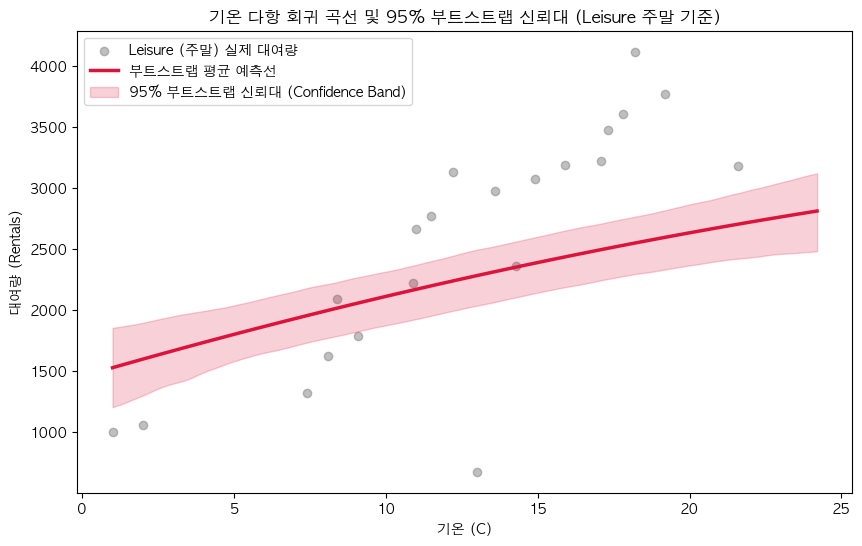

In [21]:
# [참조 실습 파일: ch05_lab_resample_t01.html]
# 다항 회귀 곡선 주변의 95% 부트스트랩 신뢰대(Confidence Band) 비모수 추정 및 시각화
# 11-2. 비선형 회귀 곡선의 부트스트랩 신뢰대 (Confidence Band)
def run_bootstrap_poly_band_robust(df, n_iterations=500):
    grid_temp = np.linspace(df['temp'].min(), df['temp'].max(), 100)
    grid_df = pd.DataFrame({
        'temp': grid_temp,
        'station_type': 'Leisure',
        'is_weekend': 1
    })
    
    # 전체 데이터에서 ModelSpec을 미리 1회 피팅 및 변환하여 에러 방지
    design = MS([poly('temp', degree=2), 'station_type', 'is_weekend'])
    X_all = design.fit_transform(df)
    y_all = df['rentals']
    X_grid = design.transform(grid_df)
    
    preds = []
    n_samples = len(df)
    for i in range(n_iterations):
        boot_indices = resample(range(n_samples), random_state=i)
        X_boot = X_all.iloc[boot_indices]
        y_boot = y_all.iloc[boot_indices]
        
        model_boot = sm.OLS(y_boot, X_boot).fit()
        preds.append(model_boot.predict(X_grid))
        
    return grid_temp, np.array(preds)

grid_temp, boot_preds = run_bootstrap_poly_band_robust(daily_df)
mean_pred = np.mean(boot_preds, axis=0)
lower_band = np.percentile(boot_preds, 2.5, axis=0)
upper_band = np.percentile(boot_preds, 97.5, axis=0)

plt.figure(figsize=(10, 6))
sub_data = daily_df[(daily_df['station_type'] == 'Leisure') & (daily_df['is_weekend'] == 1)]
plt.scatter(sub_data['temp'], sub_data['rentals'], color='gray', alpha=0.5, label='Leisure (주말) 실제 대여량')
plt.plot(grid_temp, mean_pred, color='crimson', linewidth=2.5, label='부트스트랩 평균 예측선')
plt.fill_between(grid_temp, lower_band, upper_band, color='crimson', alpha=0.2, label='95% 부트스트랩 신뢰대 (Confidence Band)')
plt.title('기온 다항 회귀 곡선 및 95% 부트스트랩 신뢰대 (Leisure 주말 기준)')
plt.xlabel('기온 (C)')
plt.ylabel('대여량 (Rentals)')
plt.legend()
plt.show()

## 12. 변수 선택 및 차원 축소 (Model Selection & Regularization - Ch 6)

과적합을 방지하고 유의미한 독립 변수를 선별하기 위해 차원 축소 및 수축 기법을 적용합니다.
- **Forward Stepwise Selection**: AIC 기준에 따라 피처를 하나씩 추가하며 AIC, BIC, $R^2$, Adjusted $R^2$의 변화를 시각화합니다.
- **Ridge Regression Shrinkage Path**: 규제 매개변수 $\alpha$에 따른 각 계수들의 축소 과정을 보여줍니다.
- **PCR 및 PLS**: 차원 축소 기법인 주성분 회귀와 부분최소제곱 모델의 주성분 수에 따른 교차검증 성능을 평가합니다.

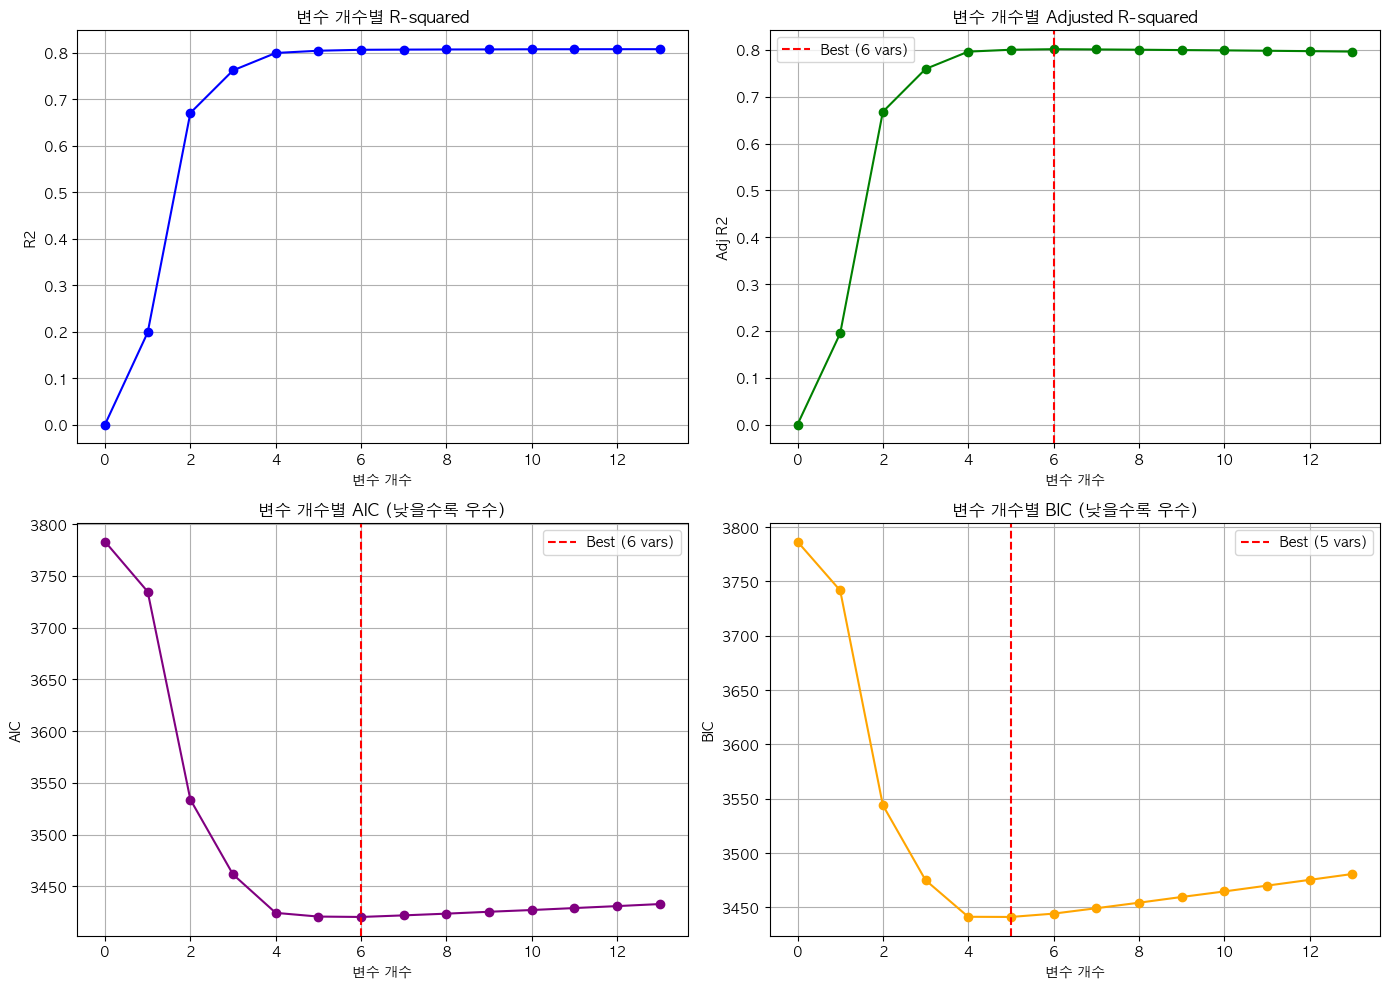

[최종 선택된 피처 리스트 (AIC 기준 최적)]
['station_Office', 'station_University', 'temp', 'precip', 'is_holiday_num', 'temp_cube']


In [22]:
# [참조 실습 파일: ch06_lab_varselect_t01.html]
# 전진 선택법(Forward Stepwise Selection)을 통한 변수 조합별 R2, Adj-R2, AIC, BIC 탐색
# 12-1. Forward Stepwise Selection 구현
def forward_stepwise_selection(df, y, feature_list):
    selected_features = []
    remaining_features = list(feature_list)
    metrics = []
    
    current_model = sm.OLS(y, sm.add_constant(pd.DataFrame(index=df.index))).fit()
    metrics.append({
        'num_features': 0,
        'features': [],
        'r2': current_model.rsquared,
        'adj_r2': 0,
        'aic': current_model.aic,
        'bic': current_model.bic
    })
    
    while remaining_features:
        best_aic = float('inf')
        best_feature = None
        best_model = None
        
        for f in remaining_features:
            candidate = selected_features + [f]
            X_cand = sm.add_constant(df[candidate])
            model_cand = sm.OLS(y, X_cand).fit()
            if model_cand.aic < best_aic:
                best_aic = model_cand.aic
                best_feature = f
                best_model = model_cand
                
        if best_feature:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            metrics.append({
                'num_features': len(selected_features),
                'features': list(selected_features),
                'r2': best_model.rsquared,
                'adj_r2': best_model.rsquared_adj,
                'aic': best_model.aic,
                'bic': best_model.bic
            })
        else:
            break
            
    return pd.DataFrame(metrics)

# 범주형 더미 및 교호작용 피처 직접 생성
analysis_df = daily_df.copy()
analysis_df['is_weekend_num'] = analysis_df['is_weekend'].astype(int)
analysis_df['is_holiday_num'] = analysis_df['is_holiday'].astype(int)
analysis_df['is_exam_num'] = analysis_df['is_exam'].astype(int)

station_dummies = pd.get_dummies(analysis_df['station_type'], prefix='station', drop_first=True).astype(int)
analysis_df = pd.concat([analysis_df, station_dummies], axis=1)

analysis_df['temp_sq'] = analysis_df['temp'] ** 2
analysis_df['temp_cube'] = analysis_df['temp'] ** 3
analysis_df['pm10_sq'] = analysis_df['pm10'] ** 2
analysis_df['temp_x_precip'] = analysis_df['temp'] * analysis_df['precip']
analysis_df['temp_x_pm10'] = analysis_df['temp'] * analysis_df['pm10']

feature_candidates = [
    'temp', 'precip', 'pm10', 'temp_sq', 'temp_cube', 'pm10_sq',
    'is_weekend_num', 'is_holiday_num', 'is_exam_num', 
    'temp_x_precip', 'temp_x_pm10', 
    'station_Office', 'station_University'
]

stepwise_results = forward_stepwise_selection(analysis_df, analysis_df['rentals'], feature_candidates)

# 다중 패널 지표 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

axes[0].plot(stepwise_results['num_features'], stepwise_results['r2'], marker='o', color='b')
axes[0].set_title('변수 개수별 R-squared')
axes[0].set_xlabel('변수 개수')
axes[0].set_ylabel('R2')
axes[0].grid(True)

axes[1].plot(stepwise_results['num_features'], stepwise_results['adj_r2'], marker='o', color='g')
best_adj_r2_idx = stepwise_results['adj_r2'].idxmax()
axes[1].axvline(stepwise_results.loc[best_adj_r2_idx, 'num_features'], color='r', linestyle='--', label=f'Best ({stepwise_results.loc[best_adj_r2_idx, "num_features"]} vars)')
axes[1].set_title('변수 개수별 Adjusted R-squared')
axes[1].set_xlabel('변수 개수')
axes[1].set_ylabel('Adj R2')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(stepwise_results['num_features'], stepwise_results['aic'], marker='o', color='purple')
best_aic_idx = stepwise_results['aic'].idxmin()
axes[2].axvline(stepwise_results.loc[best_aic_idx, 'num_features'], color='r', linestyle='--', label=f'Best ({stepwise_results.loc[best_aic_idx, "num_features"]} vars)')
axes[2].set_title('변수 개수별 AIC (낮을수록 우수)')
axes[2].set_xlabel('변수 개수')
axes[2].set_ylabel('AIC')
axes[2].legend()
axes[2].grid(True)

axes[3].plot(stepwise_results['num_features'], stepwise_results['bic'], marker='o', color='orange')
best_bic_idx = stepwise_results['bic'].idxmin()
axes[3].axvline(stepwise_results.loc[best_bic_idx, 'num_features'], color='r', linestyle='--', label=f'Best ({stepwise_results.loc[best_bic_idx, "num_features"]} vars)')
axes[3].set_title('변수 개수별 BIC (낮을수록 우수)')
axes[3].set_xlabel('변수 개수')
axes[3].set_ylabel('BIC')
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()

print("[최종 선택된 피처 리스트 (AIC 기준 최적)]")
print(stepwise_results.loc[best_aic_idx, 'features'])

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

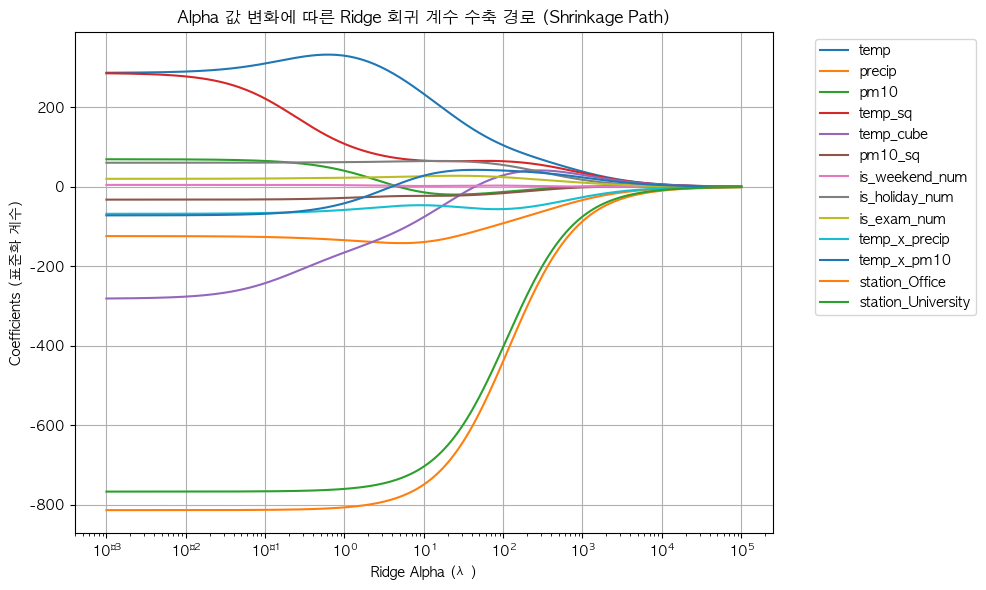

In [23]:
# [참조 실습 파일: ch06_lab_varselect_t01.html]
# sklearn.linear_model.Ridge를 활용한 규제 강도에 따른 계수 수축 경로(Shrinkage Path) 시각화
# 12-2. Ridge Regression Shrinkage Path
from sklearn.linear_model import Ridge

X_candidates = analysis_df[feature_candidates]
X_scaled_candidates = scaler.fit_transform(X_candidates)
y = analysis_df['rentals']

alphas = np.logspace(-3, 5, 200)
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_scaled_candidates, y)
    coefs.append(ridge.coef_)
    
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('Ridge Alpha (λ)')
plt.ylabel('Coefficients (표준화 계수)')
plt.title('Alpha 값 변화에 따른 Ridge 회귀 계수 수축 경로 (Shrinkage Path)')
plt.legend(feature_candidates, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

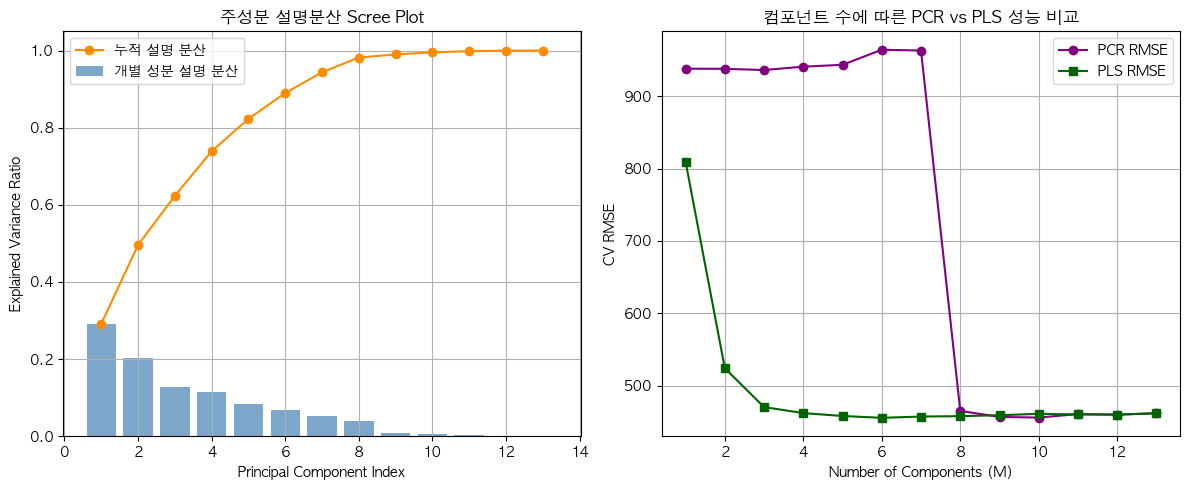

최소 PCR RMSE: 455.80 (M=10)
최소 PLS RMSE: 455.46 (M=6)


In [24]:
# [참조 실습 파일: ch06_lab_varselect_t01.html]
# PCA 주성분 회귀(PCR) 및 PLS 부분최소제곱 회귀의 성분 수별 교차 검증 RMSE 비교
# 12-3. PCR 및 PLS 적합화 및 교차 검증 비교
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression

# PCR PCA 적합
pca = PCA()
X_pca = pca.fit_transform(X_scaled_candidates)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7, color='steelblue', label='개별 성분 설명 분산')
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), marker='o', color='darkorange', label='누적 설명 분산')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('주성분 설명분산 Scree Plot')
plt.legend()
plt.grid(True)

# PCR vs PLS Cross Validation RMSE 비교
cv_kf = KFold(n_splits=5, shuffle=True, random_state=42)
pcr_rmses = []
pls_rmses = []

for m in range(1, len(feature_candidates) + 1):
    pcr_mses = []
    pls_mses = []
    for train_idx, test_idx in cv_kf.split(X_scaled_candidates):
        X_tr, X_te = X_scaled_candidates[train_idx], X_scaled_candidates[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        
        # PCR
        pca_m = PCA(n_components=m)
        X_tr_pca = pca_m.fit_transform(X_tr)
        X_te_pca = pca_m.transform(X_te)
        reg = LinearRegression()
        reg.fit(X_tr_pca, y_tr)
        pcr_preds = reg.predict(X_te_pca)
        pcr_mses.append(np.mean((y_te - pcr_preds)**2))
        
        # PLS
        pls_m = PLSRegression(n_components=m)
        pls_m.fit(X_tr, y_tr)
        pls_preds = pls_m.predict(X_te).flatten()
        pls_mses.append(np.mean((y_te - pls_preds)**2))
        
    pcr_rmses.append(np.sqrt(np.mean(pcr_mses)))
    pls_rmses.append(np.sqrt(np.mean(pls_mses)))

plt.subplot(1, 2, 2)
plt.plot(range(1, len(feature_candidates) + 1), pcr_rmses, marker='o', label='PCR RMSE', color='purple')
plt.plot(range(1, len(feature_candidates) + 1), pls_rmses, marker='s', label='PLS RMSE', color='darkgreen')
plt.xlabel('Number of Components (M)')
plt.ylabel('CV RMSE')
plt.title('컴포넌트 수에 따른 PCR vs PLS 성능 비교')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"최소 PCR RMSE: {min(pcr_rmses):.2f} (M={pcr_rmses.index(min(pcr_rmses))+1})")
print(f"최소 PLS RMSE: {min(pls_rmses):.2f} (M={pls_rmses.index(min(pls_rmses))+1})")

## 13. 고급 비선형 관계 확장 (Moving Beyond Linearity - Ch 7)

단순 선형성을 탈피하여 비선형 데이터 특성을 정교하게 적합화합니다.
- **계단 함수 (Step Functions)**: 기온 구간에 따른 대여 패턴의 불연속 변화를 분석합니다.
- **자연 스플라인 vs B-Spline**: 양 끝단(Boundary)의 외삽을 통제하는 자연 스플라인의 장점을 비교 검증합니다.
- **일반화 가산 모델 (GAM)**: 기온과 미세먼지의 비선형 기저 확장을 독립적 더미들과 가산적으로 결합하고, 변수별 부분 영향력 곡선(PDP)을 시각화합니다.

[계단 함수 모델 요약]


,coef,std err,t,P>|t|
intercept,1863.6135,70.994,26.250,0.000
temp_cut,264.8558,28.086,9.430,0.000
station_type[Office],-1725.8158,76.855,-22.455,0.000
station_type[University],-1626.8421,76.855,-21.168,0.000
is_weekend[1],-30.8660,70.220,-0.440,0.661


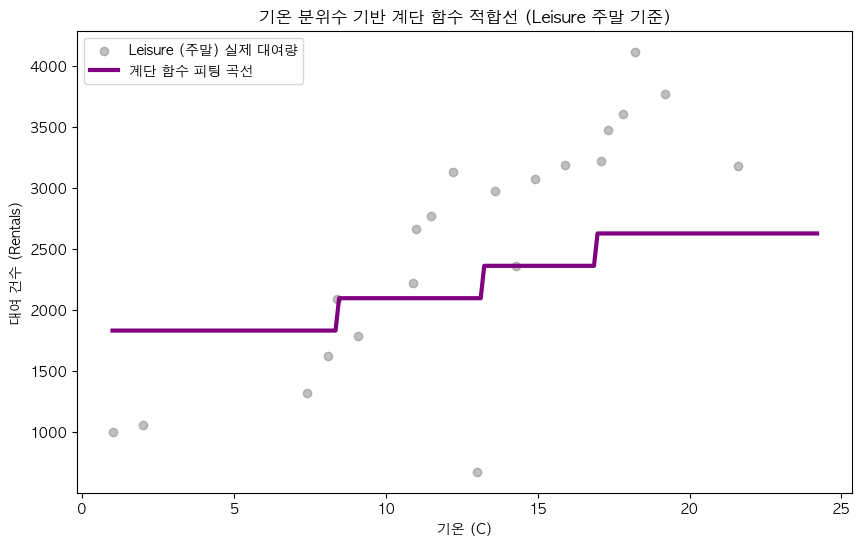

In [25]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# pd.qcut을 활용한 구간 기온 더미 기반 계단 함수(Step Functions) 적합
# 13-1. 계단 함수 (Step Functions)
daily_df['temp_cut'] = pd.qcut(daily_df['temp'], 4)
design_step = MS(['temp_cut', 'station_type', 'is_weekend'])
X_step = design_step.fit_transform(daily_df)
model_step = sm.OLS(y, X_step).fit()
print("[계단 함수 모델 요약]")
display(summarize(model_step))

# 예측선 시각화
grid_temp = np.linspace(daily_df['temp'].min(), daily_df['temp'].max(), 200)
cuts = pd.qcut(daily_df['temp'], 4, retbins=True)[1]
grid_cuts = pd.cut(grid_temp, bins=cuts, include_lowest=True)
grid_step_df = pd.DataFrame({
    'temp_cut': grid_cuts,
    'station_type': 'Leisure',
    'is_weekend': 1
})

X_grid_step = design_step.transform(grid_step_df)
preds_step = model_step.predict(X_grid_step)

plt.figure(figsize=(10, 6))
sub_data_step = daily_df[(daily_df['station_type'] == 'Leisure') & (daily_df['is_weekend'] == 1)]
plt.scatter(sub_data_step['temp'], sub_data_step['rentals'], color='gray', alpha=0.5, label='Leisure (주말) 실제 대여량')
plt.plot(grid_temp, preds_step, color='purple', linewidth=3, label='계단 함수 피팅 곡선')
plt.title('기온 분위수 기반 계단 함수 적합선 (Leisure 주말 기준)')
plt.xlabel('기온 (C)')
plt.ylabel('대여 건수 (Rentals)')
plt.legend()
plt.show()

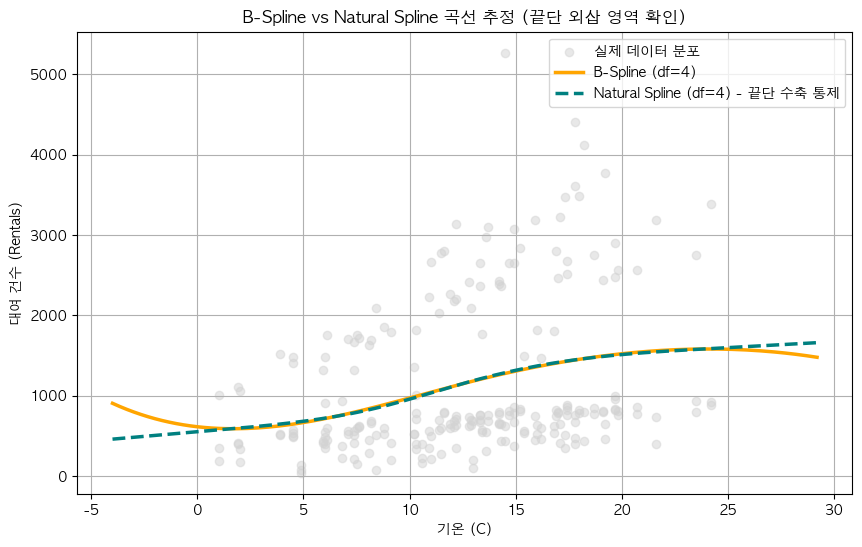

In [26]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# B-Spline(bs) vs Natural Spline(ns) 외삽 구간 예측선 시각화 비교
# 13-2. B-Spline vs Natural Spline 비교
from ISLP.models import ns

design_bs = MS([bs('temp', df=4)])
design_ns = MS([ns('temp', df=4)])

X_bs = design_bs.fit_transform(daily_df)
X_ns = design_ns.fit_transform(daily_df)

model_bs = sm.OLS(y, X_bs).fit()
model_ns = sm.OLS(y, X_ns).fit()

grid_temp_df = pd.DataFrame({'temp': np.linspace(daily_df['temp'].min() - 5, daily_df['temp'].max() + 5, 200)})
X_grid_bs = design_bs.transform(grid_temp_df)
X_grid_ns = design_ns.transform(grid_temp_df)

preds_bs = model_bs.predict(X_grid_bs)
preds_ns = model_ns.predict(X_grid_ns)

plt.figure(figsize=(10, 6))
plt.scatter(daily_df['temp'], y, color='lightgray', alpha=0.5, label='실제 데이터 분포')
plt.plot(grid_temp_df['temp'], preds_bs, color='orange', linewidth=2.5, label='B-Spline (df=4)')
plt.plot(grid_temp_df['temp'], preds_ns, color='teal', linewidth=2.5, linestyle='--', label='Natural Spline (df=4) - 끝단 수축 통제')
plt.title('B-Spline vs Natural Spline 곡선 추정 (끝단 외삽 영역 확인)')
plt.xlabel('기온 (C)')
plt.ylabel('대여 건수 (Rentals)')
plt.legend()
plt.grid(True)
plt.show()

[GAM 다중 가산 모델 요약]


,coef,std err,t,P>|t|
intercept,1254.3331,212.427,5.905,0.000
"ns(temp, df=4)[0]",684.8564,172.659,3.967,0.000
"ns(temp, df=4)[1]",920.6946,151.347,6.083,0.000
"ns(temp, df=4)[2]",1185.8433,390.281,3.038,0.003
"ns(temp, df=4)[3]",914.1057,198.525,4.604,0.000
"bs(pm10, df=3)[0]",1356.8959,419.051,3.238,0.001
"bs(pm10, df=3)[1]",-633.3562,435.426,-1.455,0.147
"bs(pm10, df=3)[2]",493.5040,303.529,1.626,0.105
station_type[Office],-1725.8158,75.758,-22.781,0.000
station_type[University],-1626.8421,75.758,-21.474,0.000


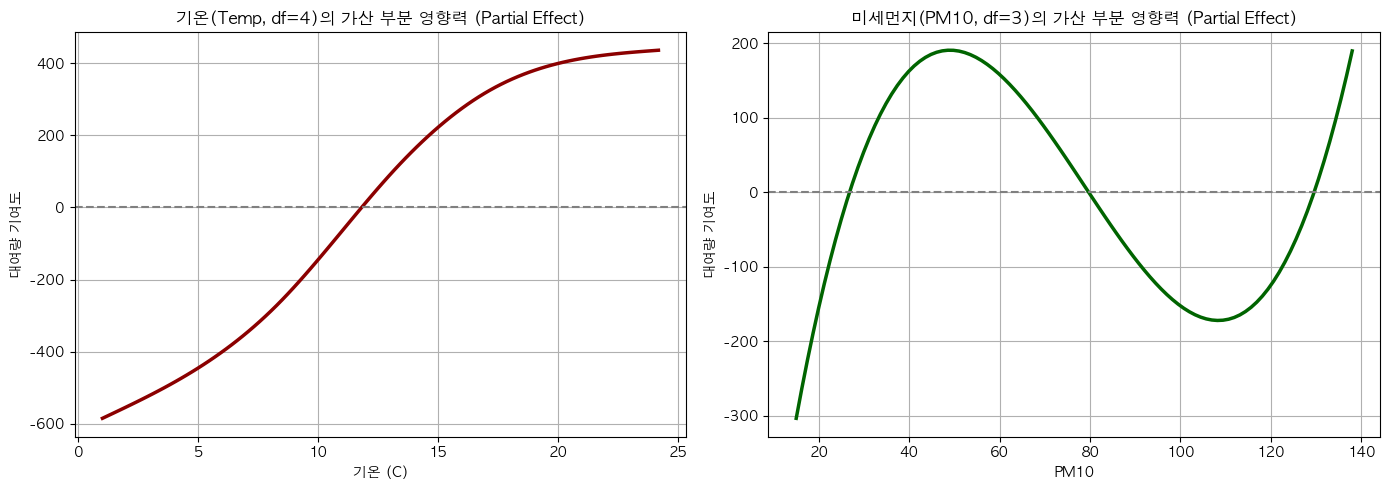

In [27]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# Natural Spline(ns)과 B-Spline(bs) 기저를 이용한 일반화 가산 모델(GAM) 적합 및 부분 영향력(Partial Effect) PDP 시각화
# 13-3. 일반화 가산 모델 (GAM) 적합 및 부분 영향력 곡선 (PDP) 시각화
# OLS를 이용한 비선형 기저항 가산 모델 구성
design_gam = MS([ns('temp', df=4), bs('pm10', df=3), 'station_type', 'is_weekend'])
X_gam = design_gam.fit_transform(daily_df)
model_gam = sm.OLS(y, X_gam).fit()
print("[GAM 다중 가산 모델 요약]")
display(summarize(model_gam))

# 기온 부분 영향력 계산
grid_temp_gam = pd.DataFrame({
    'temp': np.linspace(daily_df['temp'].min(), daily_df['temp'].max(), 100),
    'pm10': daily_df['pm10'].mean(),
    'station_type': 'Leisure',
    'is_weekend': 1
})
X_grid_temp_gam = design_gam.transform(grid_temp_gam)
preds_temp_gam = model_gam.predict(X_grid_temp_gam)
effect_temp = preds_temp_gam - np.mean(preds_temp_gam)

# 미세먼지 부분 영향력 계산
grid_pm10_gam = pd.DataFrame({
    'temp': daily_df['temp'].mean(),
    'pm10': np.linspace(daily_df['pm10'].min(), daily_df['pm10'].max(), 100),
    'station_type': 'Leisure',
    'is_weekend': 1
})
X_grid_pm10_gam = design_gam.transform(grid_pm10_gam)
preds_pm10_gam = model_gam.predict(X_grid_pm10_gam)
effect_pm10 = preds_pm10_gam - np.mean(preds_pm10_gam)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(grid_temp_gam['temp'], effect_temp, color='darkred', linewidth=2.5)
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title('기온(Temp, df=4)의 가산 부분 영향력 (Partial Effect)')
axes[0].set_xlabel('기온 (C)')
axes[0].set_ylabel('대여량 기여도')
axes[0].grid(True)

axes[1].plot(grid_pm10_gam['pm10'], effect_pm10, color='darkgreen', linewidth=2.5)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('미세먼지(PM10, df=3)의 가산 부분 영향력 (Partial Effect)')
axes[1].set_xlabel('PM10')
axes[1].set_ylabel('대여량 기여도')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 14. 시계열 의존성 진단 및 개선 (Ch 3 & Ch 5)

일별 시계열 성격의 잔차가 지닌 시간 의존성(자기상관)을 진단하고, 1일 시차 변수를 도입해 자기상관을 통제함으로써 잔차 가정을 보정하고 예측 오차를 개선합니다.
- **자기상관 진단**: ACF/PACF 플롯을 그리고 더빈-왓슨(Durbin-Watson) 검정을 수행합니다.
- **Lag-1 변수 도입**: 전날의 대여량(`rentals_lag1`)을 통제 변수로 추가한 개선된 OLS 모델을 구축하여 전후 RMSE 및 잔차의 독립성을 검증합니다.

[자기상관 진단 결과]
 - 더빈-왓슨(Durbin-Watson) 통계량: 1.1562
   (2.0에 가까우면 자기상관이 없음, 0에 가까우면 강한 양의 자기상관)


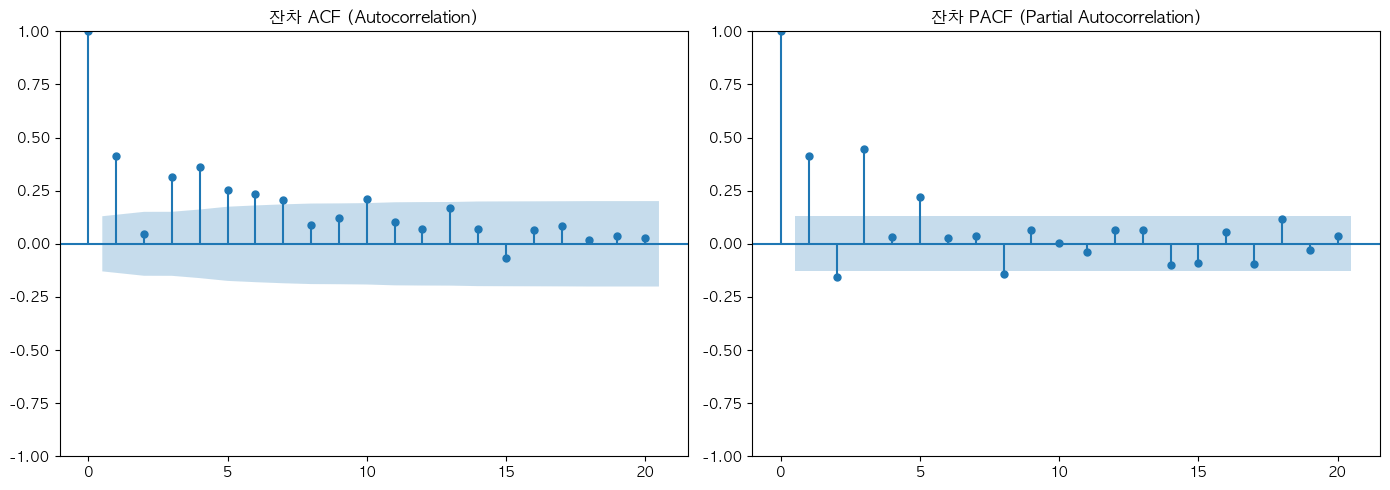

In [28]:
# [참조 실습 파일: ch03_lab_linreg_t01.html]
# statsmodels.stats.stattools.durbin_watson 및 ACF/PACF를 통한 잔차 자기상관성(Autocorrelation) 진단
# 14-1. 시계열 순서로 정렬 후 자기상관성 진단 (ACF & PACF)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson

# 상권 및 날짜별 정렬
daily_sorted = daily_df.sort_values(by=['station_type', 'date']).copy()

# 정렬된 상태에서 OLS 다시 적합
design_sorted = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', ('station_type', 'is_weekend')])
X_sorted = design_sorted.fit_transform(daily_sorted)
y_sorted = daily_sorted['rentals']
model_sorted = sm.OLS(y_sorted, X_sorted).fit()

residuals = model_sorted.resid
dw_stat = durbin_watson(residuals)
print(f"[자기상관 진단 결과]")
print(f" - 더빈-왓슨(Durbin-Watson) 통계량: {dw_stat:.4f}")
print("   (2.0에 가까우면 자기상관이 없음, 0에 가까우면 강한 양의 자기상관)")

# ACF, PACF 플롯
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(residuals, ax=axes[0], lags=20, title='잔차 ACF (Autocorrelation)')
plot_pacf(residuals, ax=axes[1], lags=20, title='잔차 PACF (Partial Autocorrelation)')
plt.tight_layout()
plt.show()

In [29]:
# [참조 실습 파일: ch03_lab_linreg_t01.html]
# 1일 시차 변수(Lag-1) 추가를 통한 자기상관성 제어 OLS 모델 적합
# 14-2. 1일 시차(Lag-1) 변수 생성 및 OLS 적합
daily_sorted['rentals_lag1'] = daily_sorted.groupby('station_type')['rentals'].shift(1)
lagged_df = daily_sorted.dropna(subset=['rentals_lag1']).copy()

# Lag-1 변수 포함 모델
design_lag = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', 
                 ('station_type', 'is_weekend'), 'rentals_lag1'])
X_lag = design_lag.fit_transform(lagged_df)
y_lag = lagged_df['rentals']

model_lag = sm.OLS(y_lag, X_lag).fit()
print("[Lag-1 변수가 추가된 개선 모델 요약]")
display(summarize(model_lag))

dw_stat_lag = durbin_watson(model_lag.resid)
print(f" - Lag-1 변수 추가 후 더빈-왓슨 통계량: {dw_stat_lag:.4f}")

[Lag-1 변수가 추가된 개선 모델 요약]


/var/folders/x8/9lffjfyx1vdf162ntg0kl4yh0000gn/T/ipykernel_74119/4288335470.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sorted['rentals_lag1'] = daily_sorted.groupby('station_type')['rentals'].shift(1)


,coef,std err,t,P>|t|
intercept,1314.7005,145.173,9.056,0.000
temp,33.4265,6.198,5.393,0.000
precip,-47.9205,6.970,-6.876,0.000
pm10,-1.3452,1.634,-0.823,0.411
station_type[Office],-1129.2853,121.849,-9.268,0.000
station_type[University],-1106.3763,118.154,-9.364,0.000
is_weekend[1],332.6591,107.717,3.088,0.002
is_holiday[1],267.3147,173.297,1.543,0.124
is_exam[1],71.3525,102.453,0.696,0.487
station_type[Office]:is_weekend,-613.8370,150.419,-4.081,0.000


 - Lag-1 변수 추가 후 더빈-왓슨 통계량: 1.5670


 - 시차 변수 제외 시 CV RMSE: 442.00
 - 시차 변수 포함 시 CV RMSE: 437.28
 - 예측 정확도 개선 효과: 1.07%


/var/folders/x8/9lffjfyx1vdf162ntg0kl4yh0000gn/T/ipykernel_74119/610462495.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['시차 변수 제외', '시차 변수 포함'], y=[rmse_no_lag, rmse_with_lag], palette='Set2')


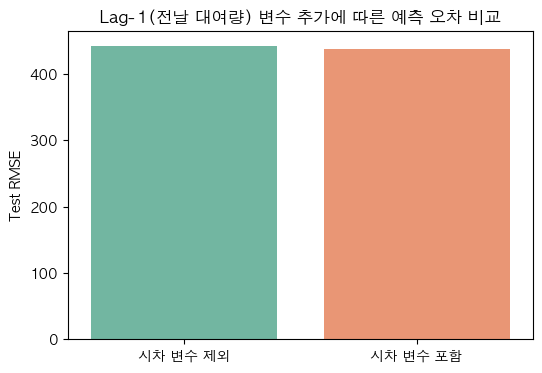

In [30]:
# [참조 실습 파일: ch05_lab_resample_t01.html]
# 교차 검증(KFold)을 통한 Lag-1 시차 모델의 예측 오차 개선 효과 검증
# 14-3. Lag-1 변수 추가에 따른 예측 정확도 (RMSE) 개선 검증
# 전체 lagged_df 데이터셋에 대해 ModelSpec을 미리 1회 피팅 및 변환하여 fold 분할 시 카테고리 누락 에러 원천 예방
ds_no_all = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', ('station_type', 'is_weekend')])
X_no_all = ds_no_all.fit_transform(lagged_df)

ds_lag_all = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', ('station_type', 'is_weekend'), 'rentals_lag1'])
X_lag_all = ds_lag_all.fit_transform(lagged_df)

y_lag_all = lagged_df['rentals']

kf_lag = KFold(n_splits=5, shuffle=True, random_state=42)

rmses_without_lag = []
rmses_with_lag = []

for train_idx, test_idx in kf_lag.split(lagged_df):
    # Without Lag-1 (미리 피팅된 X_no_all 인덱싱)
    X_tr_no = X_no_all.iloc[train_idx]
    y_tr = y_lag_all.iloc[train_idx]
    md_no = sm.OLS(y_tr, X_tr_no).fit()
    X_te_no = X_no_all.iloc[test_idx]
    preds_no = md_no.predict(X_te_no)
    rmses_without_lag.append(np.mean((y_lag_all.iloc[test_idx] - preds_no)**2))
    
    # With Lag-1 (미리 피팅된 X_lag_all 인덱싱)
    X_tr_lag = X_lag_all.iloc[train_idx]
    md_lag = sm.OLS(y_tr, X_tr_lag).fit()
    X_te_lag = X_lag_all.iloc[test_idx]
    preds_lag = md_lag.predict(X_te_lag)
    rmses_with_lag.append(np.mean((y_lag_all.iloc[test_idx] - preds_lag)**2))
    
rmse_no_lag = np.sqrt(np.mean(rmses_without_lag))
rmse_with_lag = np.sqrt(np.mean(rmses_with_lag))

print(f" - 시차 변수 제외 시 CV RMSE: {rmse_no_lag:.2f}")
print(f" - 시차 변수 포함 시 CV RMSE: {rmse_with_lag:.2f}")
print(f" - 예측 정확도 개선 효과: {(rmse_no_lag - rmse_with_lag) / rmse_no_lag * 100:.2f}%")

# 개선 효과 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=['시차 변수 제외', '시차 변수 포함'], y=[rmse_no_lag, rmse_with_lag], palette='Set2')
plt.ylabel('Test RMSE')
plt.title('Lag-1(전날 대여량) 변수 추가에 따른 예측 오차 비교')
plt.show()

## 15. 다중공선성(Multicollinearity) 진단 VIF (Ch 3)

회귀 계수의 표준오차를 팽창시켜 통계적 해석을 교란할 수 있는 다중공선성을 검정합니다.
- 다중회귀 디자인 행렬의 독립변수들에 대해 분산팽창인자(VIF)를 계산하고, 공선성 우려(VIF > 5 또는 10)가 있는 피처들을 점검합니다.

In [31]:
# [참조 실습 파일: ch03_lab_linreg_t01.html]
# statsmodels.stats.outliers_influence.variance_inflation_factor를 이용한 다중공선성(VIF) 검정
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 인터셉트(상수항) 제외한 다중회귀 피처들
X_vif_features = X_inter.drop(columns=['intercept'])

vif_data = pd.DataFrame()
vif_data["Feature (독립변수)"] = X_vif_features.columns
vif_data["VIF (분산팽창인자)"] = [variance_inflation_factor(X_vif_features.values, i) for i in range(len(X_vif_features.columns))]

print("[다중공선성 진단 VIF 결과]")
display(vif_data.sort_values(by='VIF (분산팽창인자)', ascending=False))

[다중공선성 진단 VIF 결과]


,Feature (독립변수),VIF (분산팽창인자)
0,temp,4.248941
2,pm10,4.180670
5,is_weekend[1],3.829560
9,station_type[University]:is_weekend,2.685919
8,station_type[Office]:is_weekend,2.685919
3,station_type[Office],2.482375
4,station_type[University],2.482375
7,is_exam[1],1.261987
1,precip,1.187637
6,is_holiday[1],1.064495
